Training using REINFORCE
Model loaded from saved_models/reinforce_agent_model.pth
Loaded model from saved_models/reinforce_agent_model.pth
Starting training...
Running experiment 1/100
Episode 100/200, Total Reward: 140
Episode 200/200, Total Reward: 114

Average score after 200 episodes:
  Player 1: 13.77
  Player 2: 2.49
  Player 3: 14.91
  Player 4: 7.93

Last 10 Episodes - Score Cards and Player's Cards:

Episode 1:
  Score Cards   :  4 -5  3 -4  6  7 -3  5 10 -1 -2  8  2  9  1
  Player 1 Cards:  9 13  1 14 12 10  8 11  6 15  2  4  7  5  3
  Player 2 Cards: 15 14  5 11 13 12  7 10  9  2  3  8  6  1  4
  Player 3 Cards:  3  9 13  8 11  4  7  5 14 10  6  2 12 15  1
  Player 4 Cards: 15  8  4  9 14 13  6 12  7  5  3 11  1  2 10

Episode 2:
  Score Cards   :  7 -2 -5  9 10  1 -3  6  4 -4  2 -1  8  3  5
  Player 1 Cards:  9 13  1 12 15  5 10 14 11  8  4  7  6  2  3
  Player 2 Cards: 15  5  6 14  1 13  4 12 11  8  3  7  9 10  2
  Player 3 Cards:  4  9  8  1  6  2 11 15 13 10  7 12 14  5 

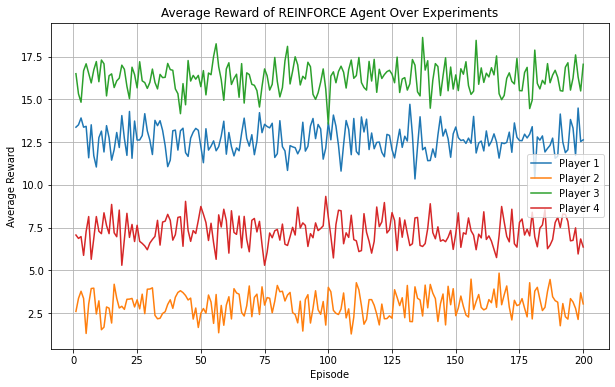

Graph saved as 'average_rewards_over_experiments.png'


<Figure size 432x288 with 0 Axes>

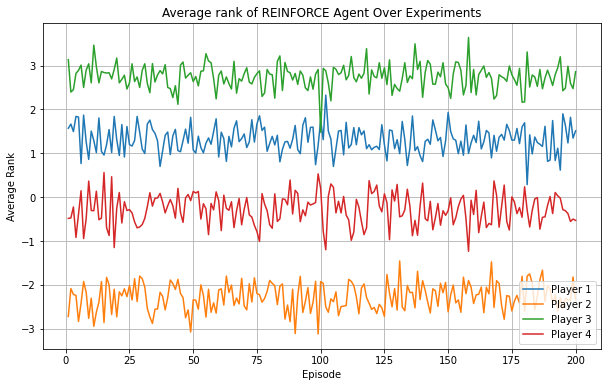

Graph saved as 'average_ranks_over_experiments.png'
Execution time: 376.0786979198456 seconds
Model saved to saved_models/reinforce_agent_model.pth
Training complete. Model saved.


<Figure size 432x288 with 0 Axes>

In [1]:
# main.py

# モジュールのインポート
from config import config                  # ハイパーパラメータの読み込み
from agent.reinforce_agent import REINFORCEAgent       # エージェントのインポートはここを変更
from environment.hagetaka_env import HagetakaEnv  # カスタム環境のインポート
from train.training_loop_v2 import train_agent  # トレーニングループのインポート

import os
import time


# モデルやログの保存用ディレクトリを作成
os.makedirs("saved_models", exist_ok=True)
os.makedirs("logs", exist_ok=True)

def main():
    # 環境とエージェントの初期化
    environment = HagetakaEnv()
    
    state_size = config['agent']['state_size']
    action_size = config['agent']['action_size']
    
    # 直接変数で指定
    algorithm = "REINFORCE"  # または "DQN"

    # エージェントの初期化
    if algorithm == 'REINFORCE':
        print("Training using REINFORCE")
        agent = REINFORCEAgent(state_size, action_size, config['agent']['learning_rate'])
        model_path = "saved_models/reinforce_agent_model.pth"
    elif algorithm == 'DQN':
        print("Training using DQN")
        agent = DQNAgent(
            state_size=state_size,
            action_size=action_size,
            learning_rate=config['agent']['learning_rate'],
            gamma=config['agent']['gamma'],
            epsilon=config['agent']['epsilon'],
            epsilon_decay=config['agent']['epsilon_decay'],
            epsilon_min=config['agent']['epsilon_min'],
            memory_size=config['agent']['memory_size'],
            batch_size=config['agent']['batch_size']
        )
        model_path = "saved_models/dqn_agent_model.pth"


    #エージェント名を変更する
    #agent = REINFORCEAgent(config['agent']['state_size'], config['agent']['action_size'], config['agent']['learning_rate'])
    
    #model_path = "saved_models/reinforce_agent_model.pth" # エージェントごとの学習状況を保存するパス
    try:
        agent.load(model_path)
        print(f"Loaded model from {model_path}")
    except FileNotFoundError:
        print(f"No model found at {model_path}. Please train the model first.")
        return

    start_time = time.time()
    
    # トレーニング開始
    print("Starting training...")
    train_agent(agent, environment, config['training']['n_episodes'], config['agent']['gamma'], config['training']['num_experiments'])  
    
    end_time = time.time()
    
    execution_time = end_time - start_time
    print(f"Execution time: {execution_time} seconds")
    
    # 学習済みモデルの保存
    agent.save("saved_models/reinforce_agent_model.pth") # エージェントごとに学習状況を保存
    print("Training complete. Model saved.")

if __name__ == "__main__":
    main()